# Batch Gradient Descent vs Stochastic Gradient Descent in PyTorch

In this notebook, We will learn:

- what gradient descent is
- what Batch Gradient Descent means
- what Stochastic Gradient Descent means
- how batch size changes the training process
- why SGD is noisier
- why Batch GD is smoother
- how to compare both using PyTorch

## 1. What is Gradient Descent?

Gradient Descent is an optimization algorithm used to reduce the loss of a model.

During training:

1. the model makes predictions
2. loss is calculated
3. gradients are computed
4. weights are updated
5. this process repeats again and again

The goal is to make the model improve over time.


## 2. What is Batch Gradient Descent?

In Batch Gradient Descent, we use the **entire dataset** to calculate the gradient before updating the weights.

That means:

- all training samples are used together
- only one update happens in one epoch
- training is usually smooth
- but updates can be slow


## 3. What is Stochastic Gradient Descent?

In Stochastic Gradient Descent (SGD), we use **one training sample at a time** to update the weights.

That means:

- batch size = 1
- many updates happen in one epoch
- learning is usually faster in terms of updates
- but the loss curve can look noisy


## 4. Main Difference

The main difference is how much data is used before one update happens.

- Batch GD → uses full dataset → one update per epoch
- SGD → uses one sample → many updates per epoch

So SGD learns more frequently, while Batch GD learns more smoothly.

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

## 5. Create a Simple Dataset

We will create a small binary classification dataset.

- input features: 2
- output: 0 or 1
- number of samples: 50

This is enough to compare Batch GD and SGD clearly.

In [9]:
torch.manual_seed(42)

X = torch.randn(50, 2)

true_w = torch.tensor([[2.0], [-3.0]])
true_b = 1.0

y = torch.sigmoid(X @ true_w + true_b)
y = (y > 0.5).float()

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: torch.Size([50, 2])
Shape of y: torch.Size([50, 1])


In [10]:
print("First 5 input samples:")
print(X[:5])

print("\nFirst 5 target values:")
print(y[:5])

First 5 input samples:
tensor([[ 1.9269,  1.4873],
        [ 0.9007, -2.1055],
        [ 0.6784, -1.2345],
        [-0.0431, -1.6047],
        [-0.7521,  1.6487]])

First 5 target values:
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [0.]])


## 6. Define a Simple Model

We will use a very simple neural network:

- input layer with 2 features
- one linear layer
- sigmoid activation for binary classification

This is enough for comparing both optimization styles.

In [11]:
class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

### Why use Sigmoid?

Sigmoid converts the output into a value between 0 and 1.

That makes it useful for binary classification, where the target is either 0 or 1.

## 7. Training Function

This function trains the model for a given batch size.

Important idea:

- `batch_size = 1` → Stochastic Gradient Descent
- `batch_size = 50` → Batch Gradient Descent

In [12]:
def train_model(batch_size, epochs=20):
    model = SimpleModel()
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1)

    dataset = TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    loss_history = []

    for epoch in range(epochs):
        epoch_loss = 0.0

        for batch_X, batch_y in loader:
            y_pred = model(batch_X)
            loss = criterion(y_pred, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        loss_history.append(avg_loss)

    return model, loss_history

### Why do we store average loss?

In SGD, one epoch has many updates.
In Batch GD, one epoch has only one update.

So storing average loss per epoch makes comparison easier.

## 8. Train Using Stochastic Gradient Descent

Here we set:

```python
batch_size = 1
```

This means the model updates its weights after every single training sample.




In [13]:
model_sgd, loss_sgd = train_model(batch_size=1, epochs=20)

## 9. Train Using Batch Gradient Descent

Here we set:

```python
batch_size = 50
```

In [14]:
model_batch, loss_batch = train_model(batch_size=50, epochs=20)

## 10. Compare Loss Curves

Now we compare how the loss changes for both methods.

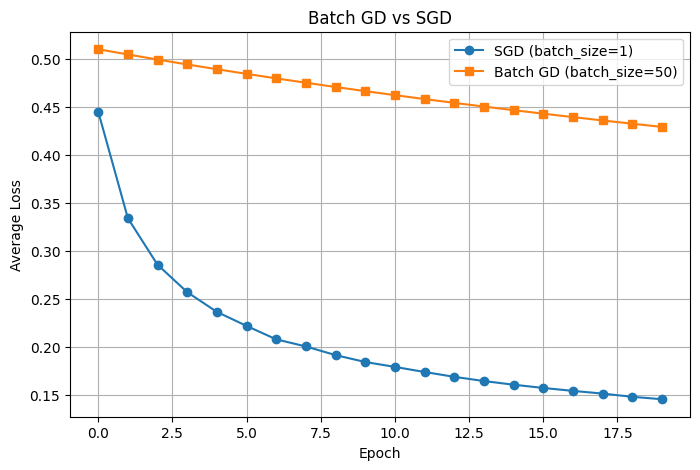

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(loss_sgd, marker='o', label="SGD (batch_size=1)")
plt.plot(loss_batch, marker='s', label="Batch GD (batch_size=50)")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Batch GD vs SGD")
plt.legend()
plt.grid(True)
plt.show()

## 11. What Do We Observe?

From the graph, we usually notice:

- SGD often drops faster in early epochs
- SGD looks more noisy because it updates after every sample
- Batch GD is smoother because it updates only once per epoch
- Batch GD may look slower when the number of epochs is small

This happens because SGD gets many more chances to update the weights.

In [16]:
print("Final SGD Loss:", loss_sgd[-1])
print("Final Batch GD Loss:", loss_batch[-1])

Final SGD Loss: 0.1450814500858405
Final Batch GD Loss: 0.42899608612060547


### Reason

This helps us compare the final training performance numerically, not just visually.

## 12. Important Practical Note

When comparing SGD and Batch GD by epoch, the comparison is not fully fair.

Why?

Because in one epoch:

- SGD performs many updates
- Batch GD performs only one update

So SGD may appear faster in terms of epochs.

A more fair comparison would be:
- compare by number of parameter updates
- or compare by wall-clock time

## 13. What About Mini-Batch Gradient Descent?

There is also a middle approach called **Mini-Batch Gradient Descent**.

Example:
- `batch_size = 8`
- `batch_size = 16`

This means:
- not one sample
- not full dataset
- but a small group of samples

Mini-batch training is the most commonly used method in deep learning because it is usually faster and more stable.

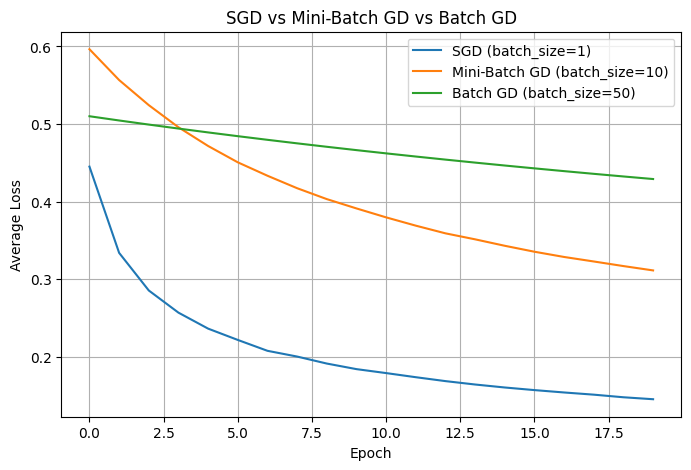

In [17]:
model_mini, loss_mini = train_model(batch_size=10, epochs=20)

plt.figure(figsize=(8, 5))
plt.plot(loss_sgd, label="SGD (batch_size=1)")
plt.plot(loss_mini, label="Mini-Batch GD (batch_size=10)")
plt.plot(loss_batch, label="Batch GD (batch_size=50)")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("SGD vs Mini-Batch GD vs Batch GD")
plt.legend()
plt.grid(True)
plt.show()

## 14. Final Conclusion

In this notebook, We learned:

- Gradient Descent updates model weights to reduce loss
- Batch Gradient Descent uses the full dataset before one update
- Stochastic Gradient Descent uses one sample before one update
- SGD usually learns faster in terms of updates
- SGD produces noisier loss curves
- Batch GD is smoother but may look slower
- Mini-batch gradient descent is often the practical choice in deep learning